In [19]:
from auditoryforage.utils import open_pickle_file
folder_name = './store/comparison/'
file_name = folder_name + 'diff_food_rewards.pkl'
detection_measures = open_pickle_file(file_name)

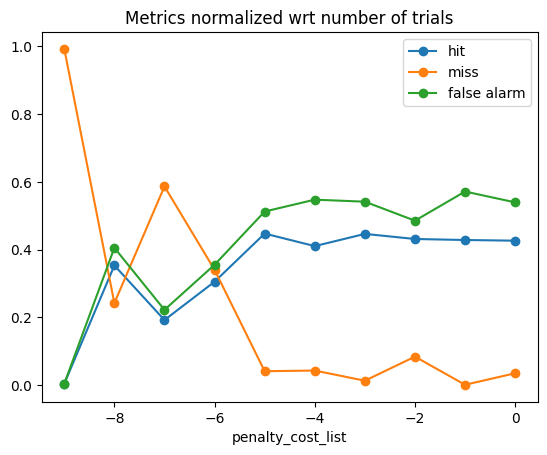

In [40]:
import numpy as np
import matplotlib.pyplot as plt
# food_reward_list = detection_measures['input']['food_reward_list']
penalty_cost_list = detection_measures['input']['penalty_cost_list']
# max_food_ind = len(food_reward_list)
# max_ind = 9
max_ind = -10

# Plotting any one seed
max_ind_list = detection_measures['output']['best_seed_list']

# Plotting best case scenario
# max_ind_list = [count.index(max(count)) for count in detection_measures['output']['hit_count_list']]

max_hit_count_normalized = [np.array(count[max_ind_list[ind]])/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['hit_count_list'])]
max_miss_count_normalized = [np.array(count[max_ind_list[ind]])/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['miss_count_list'])]
max_false_alarm_count_normalized = [count[max_ind_list[ind]]/detection_measures['input']['no_episodes'] for ind, count in enumerate(detection_measures['output']['false_alarm_list'])]
plt.plot(penalty_cost_list[:max_ind], max_hit_count_normalized[:max_ind], 'o-')
plt.plot(penalty_cost_list[:max_ind], max_miss_count_normalized[:max_ind], 'o-')
plt.plot(penalty_cost_list[:max_ind], max_false_alarm_count_normalized[:max_ind], 'o-')
plt.legend(['hit', 'miss', 'false alarm'])
plt.xlabel('penalty_cost_list')
plt.title('Metrics normalized wrt number of trials')
plt.show()

In [4]:
print(penalty_cost_list[:max_food_ind])
print(max_hit_count_normalized[:max_food_ind])
print(max_miss_count_normalized[:max_food_ind])
print(max_false_alarm_count_normalized[:max_food_ind])

[0, 5.0, 10.0, 15.0, 20.0, 25.0, 50.0, 75.0, 100.0]
[0.0, 0.342, 0.449, 0.511, 0.478, 0.785, 0.819, 0.792, 0.807]
[0.001, 0.0, 0.013, 0.198, 0.016, 0.079, 0.067, 0.084, 0.079]
[0.999, 0.658, 0.538, 0.291, 0.506, 0.136, 0.114, 0.124, 0.114]


In [25]:
print(penalty_cost_list[:max_food_ind])
print(max_hit_count_normalized[:max_food_ind])
print(max_miss_count_normalized[:max_food_ind])
print(max_false_alarm_count_normalized[:max_food_ind])

[0, 5.0, 10.0, 15.0, 20.0, 25.0, 50.0, 75.0, 100.0]
[0.0, 0.418, 0.443, 0.511, 0.484, 0.483, 0.781, 0.801, 0.795]
[0.001, 0.001, 0.012, 0.198, 0.016, 0.011, 0.059, 0.037, 0.08]
[0.999, 0.581, 0.545, 0.291, 0.5, 0.506, 0.16, 0.162, 0.125]


ValueError: x and y must have same first dimension, but have shapes (0,) and (8,)

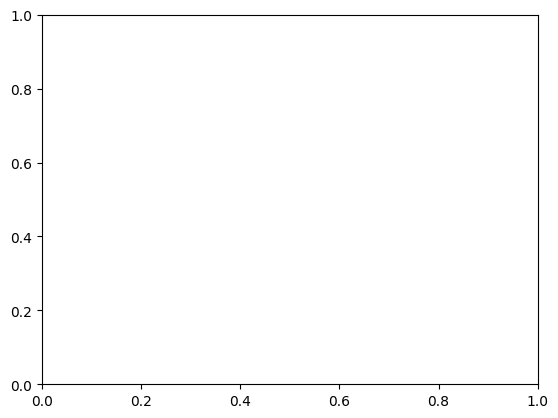

In [26]:
import numpy as np
import matplotlib.pyplot as plt
# food_reward_list = detection_measures['input']['food_reward_list']
# max_food_ind = len(food_reward_list)
penalty_cost_list = [0, .25, .5, .75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3]
min_food_ind = 1
max_food_ind = 9
one_step_in_seconds = .001

# Plotting any one seed
# max_ind_list = [2 for rate_list in detection_measures['output']['hit_count_list']]

# Plotting best case scenario
max_ind_list = [rate_list.index(max(rate_list)) for rate_list in detection_measures['output']['hit_count_list']]

temp_zip = zip(np.arange(len(max_ind_list)), detection_measures['output']['hit_count_list'], detection_measures['output']['signal_time_before_lick_list'])
max_hit_rate = [np.divide(count[max_ind_list[ind]],(duration[max_ind_list[ind]] * one_step_in_seconds)) for ind, count, duration in temp_zip]
temp_zip = zip(np.arange(len(max_ind_list)), detection_measures['output']['false_alarm_list'], detection_measures['output']['noise_time_before_lick_list'])
max_false_alarm_rate = [np.array(count[max_ind_list[ind]])/(duration[max_ind_list[ind]] * one_step_in_seconds) for ind, count, duration in temp_zip]
plt.plot(food_reward_list[min_food_ind:max_food_ind], max_hit_rate[min_food_ind:max_food_ind], 'o-')
plt.plot(food_reward_list[min_food_ind:max_food_ind], max_false_alarm_rate[min_food_ind:max_food_ind], 'o-')
plt.legend(['hit', 'false alarm'])
plt.xlabel('food_reward_list')
plt.title('Metrics normalized wrt categorical duration')
plt.show()

ValueError: x and y must have same first dimension, but have shapes (1,) and (5, 5)

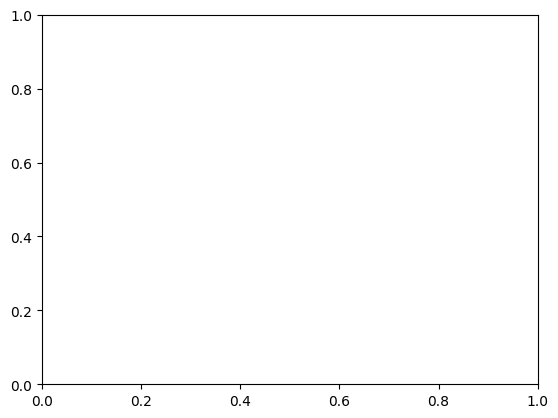

In [23]:
# Plotting all scenarios
import matplotlib.pyplot as plt
food_reward_list = detection_measures['input']['food_reward_list']

# max_food_ind = len(food_reward_list)
max_food_ind = 5

hit_count_list = detection_measures['output']['hit_count_list']
miss_count_list = detection_measures['output']['miss_count_list']
false_alarm_list = detection_measures['output']['false_alarm_list']
plt.plot(food_reward_list[:max_food_ind], hit_count_list[:max_food_ind], '-')
plt.plot(food_reward_list[:max_food_ind], miss_count_list[:max_food_ind], '--')
plt.plot(food_reward_list[:max_food_ind], false_alarm_list[:max_food_ind], '.-')
plt.xlabel('food_reward_list')
plt.show()

In [46]:
# # Adding new data to pickle file

# from auditoryforage.utils import open_pickle_file

# folder_name = './store/comparison/'
# name_1 = 'diff_food_rewards'
# name_2 = 'full_diff_food_rewards'

# file_name_1 = folder_name + name_1 +'.pkl'
# detection_measures_1 = open_pickle_file(file_name_1)
# food_reward_list_1 = detection_measures_1['input']['food_reward_list']

# file_name_2 = folder_name + name_2 +'.pkl'
# detection_measures_2 = open_pickle_file(file_name_2)
# food_reward_list_2 = detection_measures_2['input']['food_reward_list']

# full_food_reward_list = food_reward_list_1 + food_reward_list_2
# sorted_food_reward_list = sorted(full_food_reward_list)

# detection_measures = {}
# detection_measures['input'] = {}
# detection_measures['output'] = {}
# detection_measures['input']['food_reward_list'] = sorted_food_reward_list
# detection_measures['output'] = {}
# detection_measures['output']['hit_count_list'] = []
# detection_measures['output']['miss_count_list'] = []
# detection_measures['output']['false_alarm_list'] = []

# for food_reward in sorted_food_reward_list:
#     if food_reward in food_reward_list_1:
#         index = food_reward_list_1.index(food_reward)
#         detection_measures['output']['hit_count_list'].append(detection_measures_1['output']['hit_count_list'][index])
#         detection_measures['output']['miss_count_list'].append(detection_measures_1['output']['miss_count_list'][index])
#         detection_measures['output']['false_alarm_list'].append(detection_measures_1['output']['false_alarm_list'][index])
#     elif food_reward in food_reward_list_2:
#         index = food_reward_list_2.index(food_reward)
#         detection_measures['output']['hit_count_list'].append(detection_measures_2['output']['hit_count_list'][index])
#         detection_measures['output']['miss_count_list'].append(detection_measures_2['output']['miss_count_list'][index])
#         detection_measures['output']['false_alarm_list'].append(detection_measures_2['output']['false_alarm_list'][index])
#     else:
#         print("Something wrong")

# from auditoryforage.utils import save_pickle_file
# file_name = folder_name + 'combined_diff_food_rewards.pkl'
# save_pickle_file(detection_measures, file_name)

In [12]:
# 0 penalty
print(max_hit_count_normalized)
print(max_miss_count_normalized)
print(max_false_alarm_count_normalized)

[0.283]
[0.0]
[0.717]


In [37]:
# -1 penalty
print(max_hit_count_normalized)
print(max_miss_count_normalized)
print(max_false_alarm_count_normalized)

[0.324]
[0.269]
[0.407]


In [27]:
# -2 penalty
print(max_hit_count_normalized)
print(max_miss_count_normalized)
print(max_false_alarm_count_normalized)

[0.344]
[0.232]
[0.424]


In [23]:
# -5 penalty
print(max_hit_count_normalized)
print(max_miss_count_normalized)
print(max_false_alarm_count_normalized)

[0.065]
[0.853]
[0.082]


In [20]:
# -10 penalty
print(max_hit_count_normalized)
print(max_miss_count_normalized)
print(max_false_alarm_count_normalized)

[0.009]
[0.979]
[0.012]


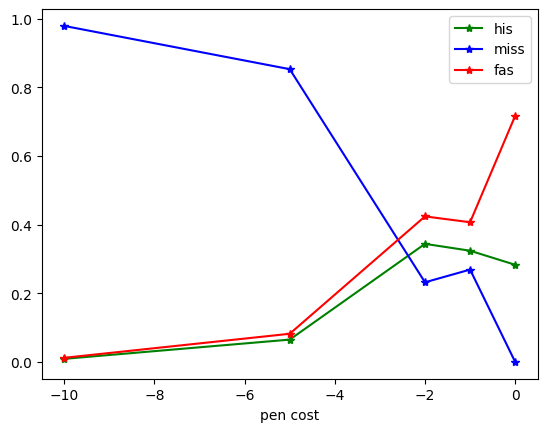

In [28]:
pen_cost = [0, -1, -2, -5, -10]
hits = [0.283, 0.324, 0.344, 0.065, 0.009]
misses = [0, 0.269, 0.232, 0.853, 0.979]
fas = [0.717, 0.407, 0.424, 0.082, 0.012]

plt.plot(pen_cost, hits, 'g*-')
plt.plot(pen_cost, misses, 'b*-')
plt.plot(pen_cost, fas, 'r*-')
plt.xlabel('pen cost')
plt.legend(['his','miss','fas'])
plt.show()


In [30]:
print(max_ind_list)
print(detection_measures['output']['best_seed_list'])

[1, 0, 0, 1, 2, 0, 3, 1, 2, 0, 1, 1, 3, 0, 4, 1, 3, 4, 4, 2]
[0, 0, 0, 0, 0, 1, 1, 4, 1, 2, 4, 4, 0, 4, 2, 0, 1, 3, 3, 3]
